# Controversy Axes in UK Parliamentary Debates: an LLM-driven approach


## Abstract
The increasing volume of political information, combined with the spread of 
misinformation, makes it difficult for citizens to track and interpret 
parliamentary debate. This work presents an NLP pipeline for automatic stance 
detection and controversy analysis applied to real UK parliamentary data 
(ParlEE Plenary Speeches V2 dataset [1], 2009–2019).

The proposed methodology consists of the following steps:
1. Topic selection and speech filtering by keyword and policy area
2. Opinion sentence detection via a fine-tuned classification model
3. Per-politician stance summarization using a local LLM
4. Issue identification and anchor generation along controversy axes
5. Embedding-based projection of party stances onto axes of controversy
6. Visualization of party positions on each axis

The approach is inspired by the KOKKAI DOC framework [2] and is evaluated 
on topics including the Israeli-Palestinian conflict, climate change and nuclear energy.

## The notebook

In [1]:
import pandas as pd
import os
import sys
sys.path.append("./../src")
from setfit import SetFitModel
from rouge_score import rouge_scorer
import json
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from datasets import load_dataset
from StanceDetector import StanceDetector
import utils

random_seed=41


c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

For this work we use a reduced version of the ParlEE Plenary Speeches V2 
dataset [1], available on HuggingFace as `andreacristiano/uk_parliament`. 
The dataset contains UK parliamentary debates spanning from 2009 to 2019, 
where each entry represents a single speech by a Member of Parliament (MP).

The dataset contains the following columns:

| Column | Description |
|---|---|
| `date` | Date of the parliamentary session |
| `agenda` | Brief description of the discussion topic |
| `speaker` | Full name of the MP |
| `party` | Party acronym (e.g. `Lab`, `Con`, `LD`) |
| `text` | Text of the intervention |
| `policyarea` | Numeric code identifying the policy area |
| `year` | Year of the discussion |

In [2]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

Loading ```records.json```. This file contains keyword and policy area codes that will be later used to filter the speeches in the dataset.

In [3]:
# read records from json file
with open('./../data/external/records.json', 'r') as f:
    records = json.load(f) 


In [4]:
uk = StanceDetector(df1, records, random_seed=random_seed)

c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Gaza

The first topic we are going to analyze is 'Gaza'. We are going to consider all the debates revolving around the Israeli-Palestinian conflict.

In [14]:
topic='Gaza'
years = [2011, 2012, 2013, 2014]

### First part of the pipeline
1. Filtering speeches by keyword and policy area
2. Detecting opinion-based speeches
3. Summarizing the stance of each politician

In [7]:

filtered_df= uk.filter_speeches(topic, years=years) 
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)


Filtering speeches for topic: Gaza
Number of speeches after filtering for topic 'Gaza' in years [2011, 2012, 2013, 2014]: 1547
Classifying filtered speeches for topic: Gaza
"Number of opinionated speeches for Gaza: 238
Summarization completed for topic: Gaza


In [ ]:
os.makedirs('./../data/processed', exist_ok=True)
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [15]:
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
uk.set_summarization_for_topic(topic, summarizations)

### Topics and Axes of Controversy

For each topic of interest, we define an **issue** to analyze and a pair of **stance anchors** — short 
textual descriptions representing the two opposing poles of the debate 
(labeled `PRO` and `CON`). These anchors are embedded in the same vector 
space as the speaker summaries, and the axis connecting them defines the 
**axis of controversy** along which each party's position is projected.

For each topic we distinguish between:
- A **general issue** (`general_anchors`): a broad framing of the overall debate
- **Sub-issues** (`anchors`): more specific contested questions identified 
  within the topic

Both are generated by an LLM from the aggregated speaker summaries.

In [16]:
# generated with Claude Sonnet 4.6 (thinking mode)
general_anchors = {
    "topic": "The primary obstacle to peace in the Israeli-Palestinian conflict",
    "pro": (
        "Israeli military actions, settlement expansion, and the blockade of Gaza "
        "are the primary obstacles to a just and lasting peace, causing humanitarian "
        "suffering and undermining the viability of a Palestinian state."
    ),
    "con": (
        "Hamas's terrorism, its rejection of Israel's right to exist, and its use "
        "of violence are the fundamental barriers to any negotiated resolution "
        "and a stable two-state solution."
    )
}


In [14]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: Gaza


In [ ]:
with open(f'./../data/processed/anchors_{topic}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [8]:
with open(f'./../data/processed/anchors_{topic}.json', 'r') as f:
    anchors = json.load(f)

### Analysis and Visualization

Once the anchors are defined, party positions are scaled along the axis 
of controversy through the following steps:

1. **UMAP Visualization** — Speaker embeddings are reduced to 2D using UMAP 
   to inspect the distribution of positions in the embedding space, identify 
   clusters and outliers, and verify anchor separation. Party centroids are 
   also shown as a reference for the average position per party. Note that 
   UMAP is used for exploratory visualization only; the actual scoring is 
   performed in the original high-dimensional embedding space.

2. **Axis Projection** — Using `axis_of_controversy()`, party centroids are 
   projected onto the controversy axis via scalar projection, yielding a 
   controversy score for each party. Parties are ranked from the most 
   `CON`-aligned to the most `PRO`-aligned.

Finally, the predicted party ordering is validated against a gold 
   standard ranking generated by an LLM-as-a-judge framework 
   (see [Validation](#validation) section).

Computing UMAP embeddings for topic: Gaza
Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.57s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


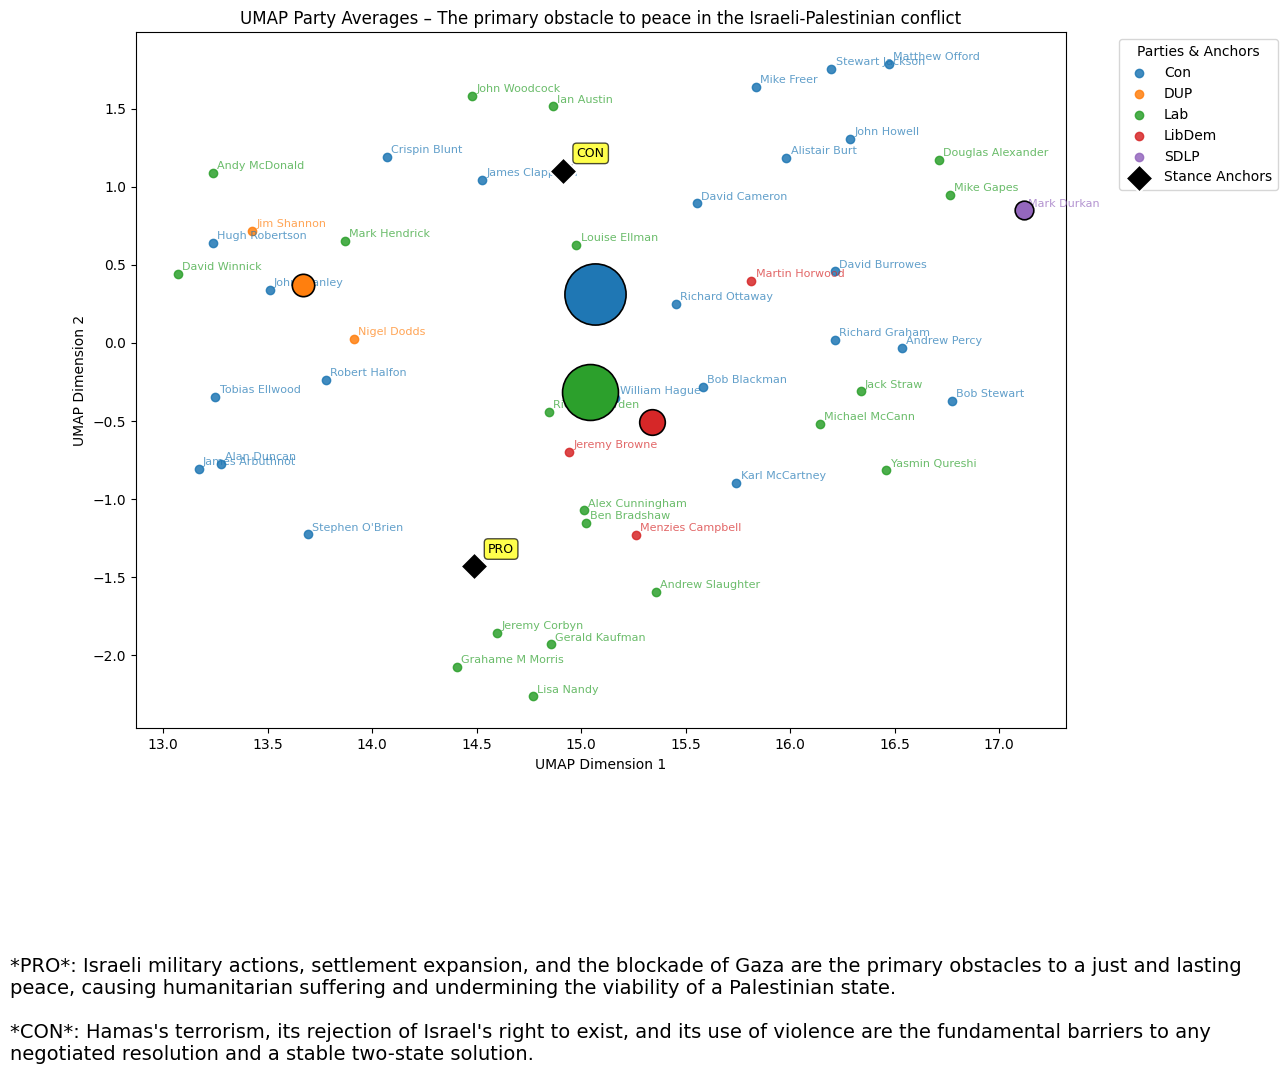

In [17]:
embeddings = uk.compute_umap_embeddings(topic, general_anchors)
uk.plot_umap_party_averages(embeddings, topic)

In [18]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)


# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.61s/it]

Cosine similarity between anchor embeddings:
0.6801569


,party,controversy_score,issue
1,DUP,-0.101363,The primary obstacle to peace in the Israeli-P...
0,Con,-0.090562,The primary obstacle to peace in the Israeli-P...
4,SDLP,-0.072327,The primary obstacle to peace in the Israeli-P...
2,Lab,0.005217,The primary obstacle to peace in the Israeli-P...
3,LibDem,0.023792,The primary obstacle to peace in the Israeli-P...


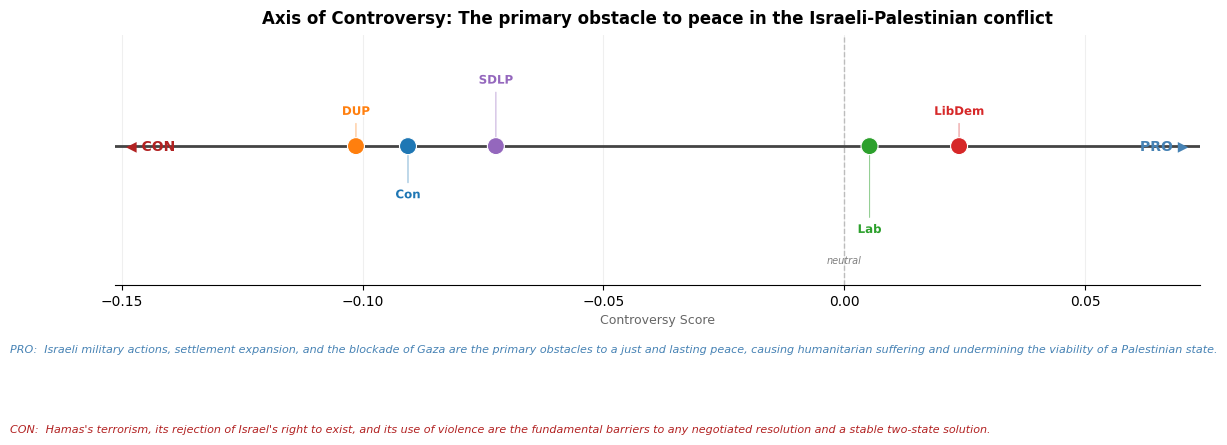

In [19]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

<a id="validation"></a>
### Validation

After obtaining a party ordering along the controversy axis for a given topic, 
it is necessary to assess its validity. This task is typically performed by 
a human evaluator; however, to keep the pipeline fully automated, we adopt 
an **LLM-as-a-judge** approach.

Through `generate_gold_standard()`, an LLM is prompted to rank the parties 
along the controversy axis based on general political knowledge. For this task 
we use `qwen3:8b` with thinking mode enabled, as the zero-shot ranking of 
political parties requires a model with sufficient compressed world knowledge.

The predicted ordering is then compared against the gold standard using 
three rank-based metrics:

- **Spearman's ρ** — Measures the correlation between two rankings. A value 
  of +1 indicates perfect agreement, -1 perfect disagreement, and 0 no 
  correlation. The associated p-value indicates the probability of observing 
  such correlation by chance.

- **Kendall's τ** — Measures the proportion of concordant vs discordant pairs 
  in the two rankings. More robust than Spearman's ρ under small sample sizes, 
  which is relevant given the limited number of UK parties.

- **LCS ratio** — The length of the Longest Common Subsequence between the 
  two orderings, normalized by the total number of parties. More interpretable 
  than p-value significance tests in low-power regimes, as it directly 
  captures how much of the predicted ordering matches the gold standard.

In [20]:
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=general_anchors, years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
gaza_general_metrics = metrics
print(metrics)

Predicted ordering: ['DUP', 'Con', 'SDLP', 'Lab', 'LibDem']
Gold standard ordering: ['Con', 'DUP', 'Lab', 'LibDem', 'SDLP']
{'spearman_rho': np.float64(0.6), 'spearman_p': np.float64(0.2848), 'kendall_tau': np.float64(0.4), 'kendall_p': np.float64(0.4833), 'lcs_ratio': 0.6, 'n_parties': 5}


In [21]:
# saving general metrics to json file
with open(f'./../data/processed/general_metrics_{topic}.json', 'w') as f:
    json.dump(gaza_general_metrics, f, indent=4)

In [22]:
# loading general metrics from json file
with open(f'./../data/processed/general_metrics_{topic}.json', 'r') as f:
    gaza_general_metrics = json.load(f)

### Analysis on Sub-topics

The analysis was then repeated on the sub-topics generated automatically 
by the anchor generation step. Performance tends to degrade compared to 
results obtained on the general issue, likely for two compounding reasons:

- **Summarization granularity** — Speaker summaries are generated at the 
  topic level, and may not capture the nuances required to accurately 
  represent a party's position on each individual sub-topic.
- **Sparse signal** — Some parties have few representatives in the filtered 
  speeches, making their centroid estimates less reliable on narrower issues.

Computing UMAP embeddings for topic: Gaza
Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.85s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


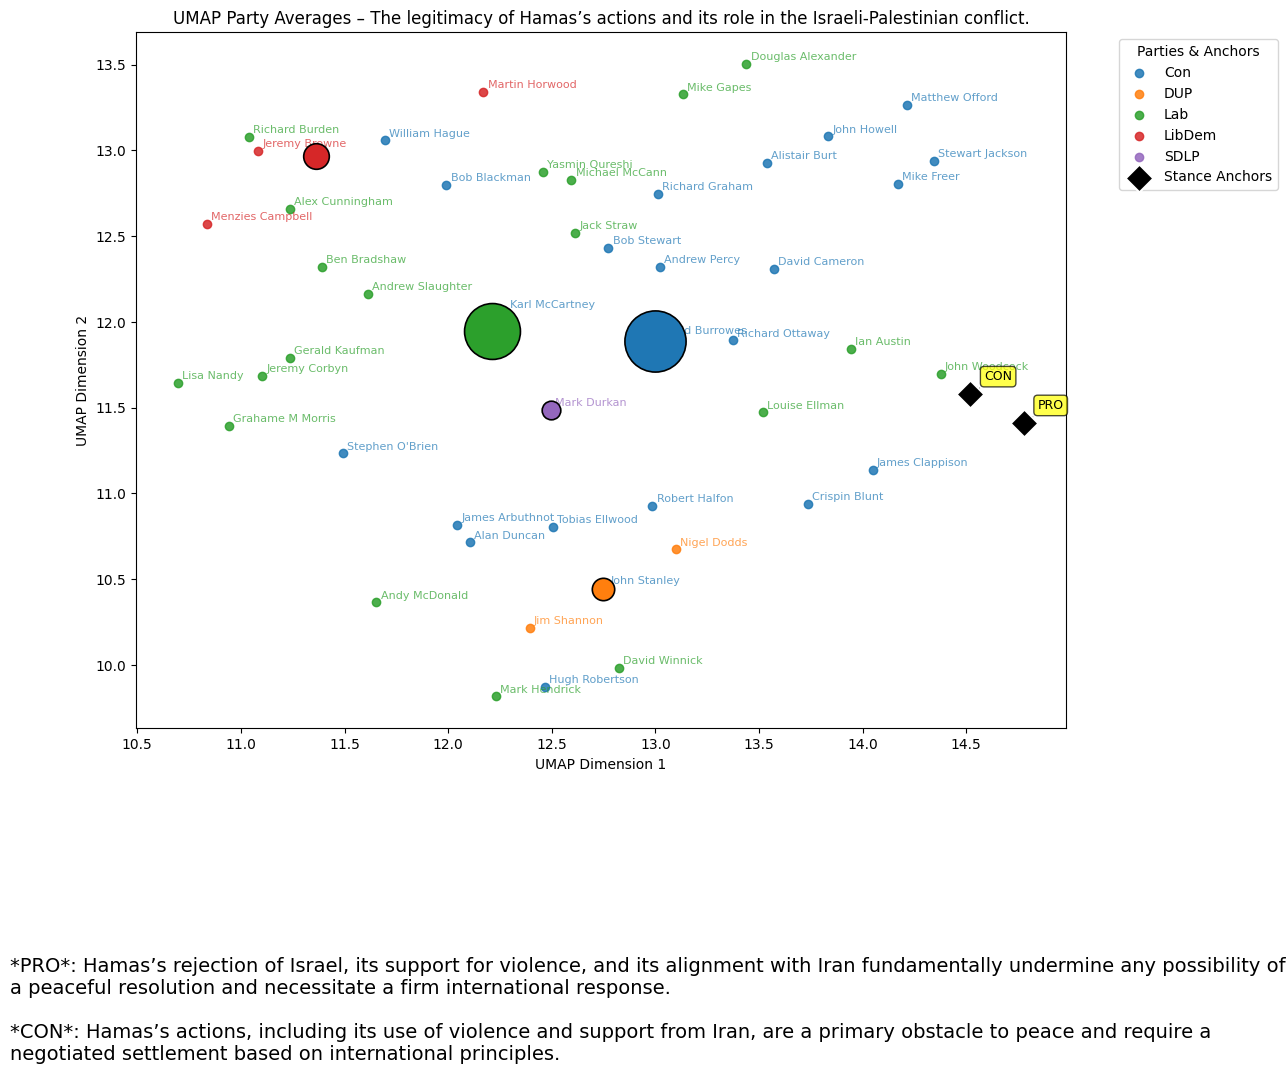

In [14]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [15]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[0])

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = anchors[0]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.43s/it]

Cosine similarity between anchor embeddings:
0.8926584


,party,controversy_score,issue
2,Lab,0.017916,The legitimacy of Hamas’s actions and its role...
0,Con,0.024004,The legitimacy of Hamas’s actions and its role...
3,LibDem,0.060119,The legitimacy of Hamas’s actions and its role...
4,SDLP,0.068212,The legitimacy of Hamas’s actions and its role...
1,DUP,0.077473,The legitimacy of Hamas’s actions and its role...


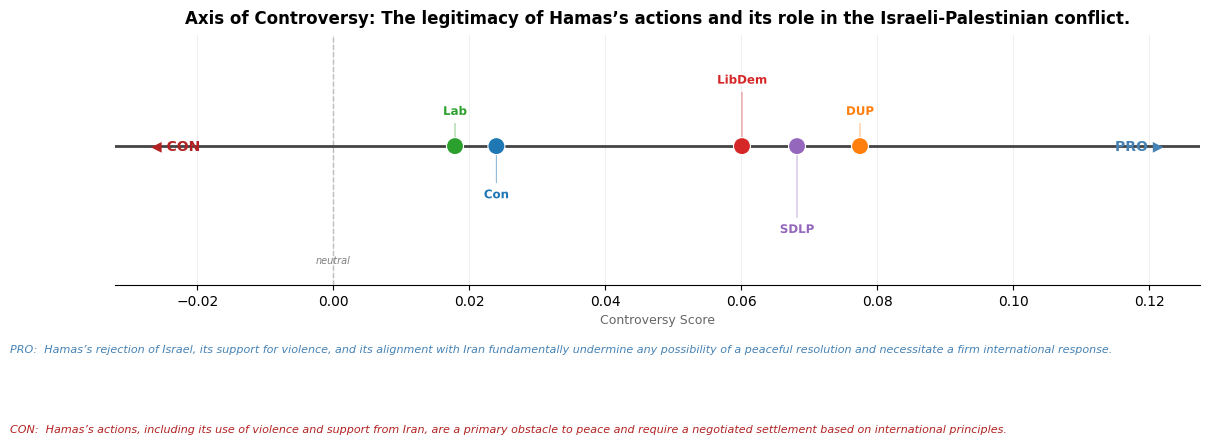

In [16]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[0])

In [17]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[0], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
if 'gaza_metrics_by_anchor' not in globals():
    gaza_metrics_by_anchor = {}
gaza_metrics_by_anchor[0] = metrics
print(metrics)

Predicted ordering: ['Lab', 'Con', 'LibDem', 'SDLP', 'DUP']
Gold standard ordering: ['Lab', 'LibDem', 'SDLP', 'DUP', 'Con']
{'spearman_rho': np.float64(0.4), 'spearman_p': np.float64(0.5046), 'kendall_tau': np.float64(0.4), 'kendall_p': np.float64(0.4833), 'lcs_ratio': 0.8, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza
Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.88s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


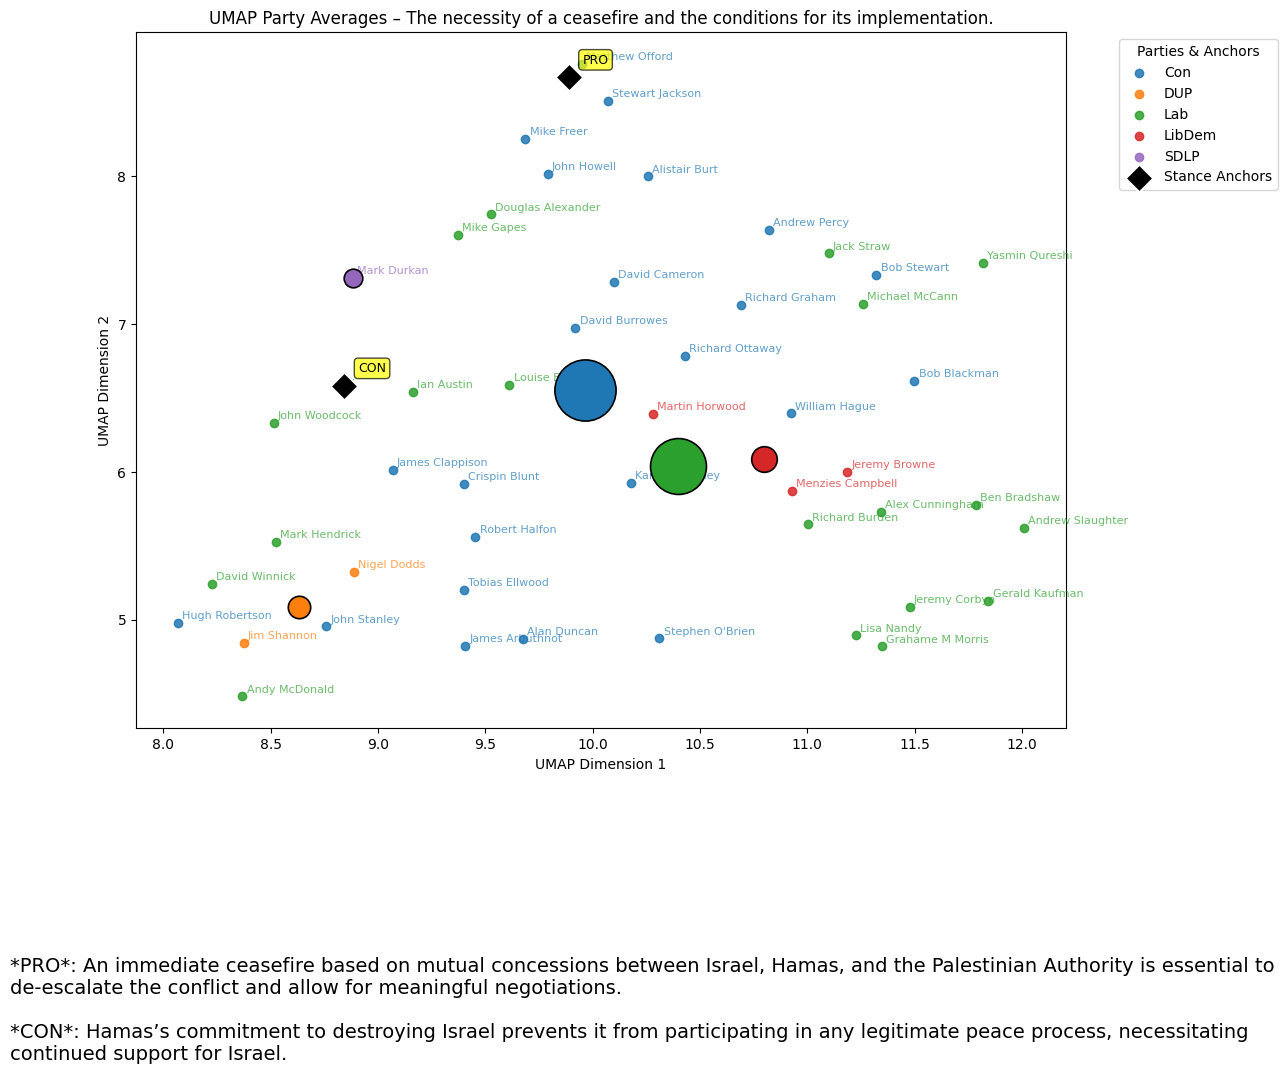

In [18]:
embeddings = uk.compute_umap_embeddings(topic, anchors[2])
uk.plot_umap_party_averages(embeddings, topic)

In [19]:
# compute controversy axis based on anchor 1 (pro) and anchor 0 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[2])

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)


issue = anchors[2]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.78s/it]

Cosine similarity between anchor embeddings:
0.6429279


,party,controversy_score,issue
1,DUP,-0.171655,The necessity of a ceasefire and the condition...
4,SDLP,-0.099125,The necessity of a ceasefire and the condition...
2,Lab,-0.087337,The necessity of a ceasefire and the condition...
0,Con,-0.080203,The necessity of a ceasefire and the condition...
3,LibDem,-0.074770,The necessity of a ceasefire and the condition...


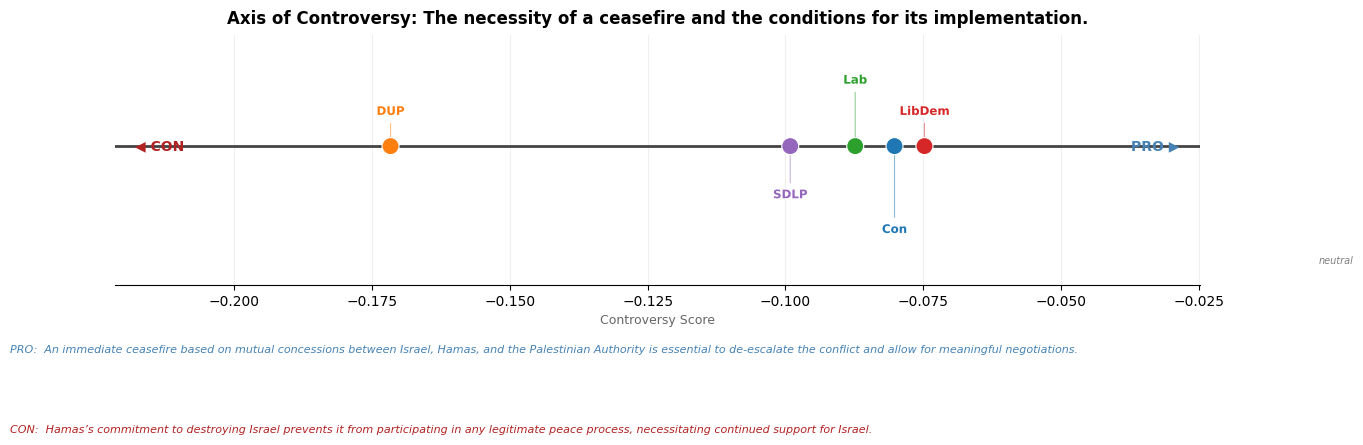

In [20]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[2])

In [22]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[2], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
if 'gaza_metrics_by_anchor' not in globals():
    gaza_metrics_by_anchor = {}
gaza_metrics_by_anchor[2] = metrics
print(metrics)

Predicted ordering: ['DUP', 'SDLP', 'Lab', 'Con', 'LibDem']
Gold standard ordering: ['DUP', 'Con', 'Lab', 'LibDem', 'SDLP']
{'spearman_rho': np.float64(0.3), 'spearman_p': np.float64(0.6238), 'kendall_tau': np.float64(0.2), 'kendall_p': np.float64(0.8167), 'lcs_ratio': 0.6, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza
Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.54s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


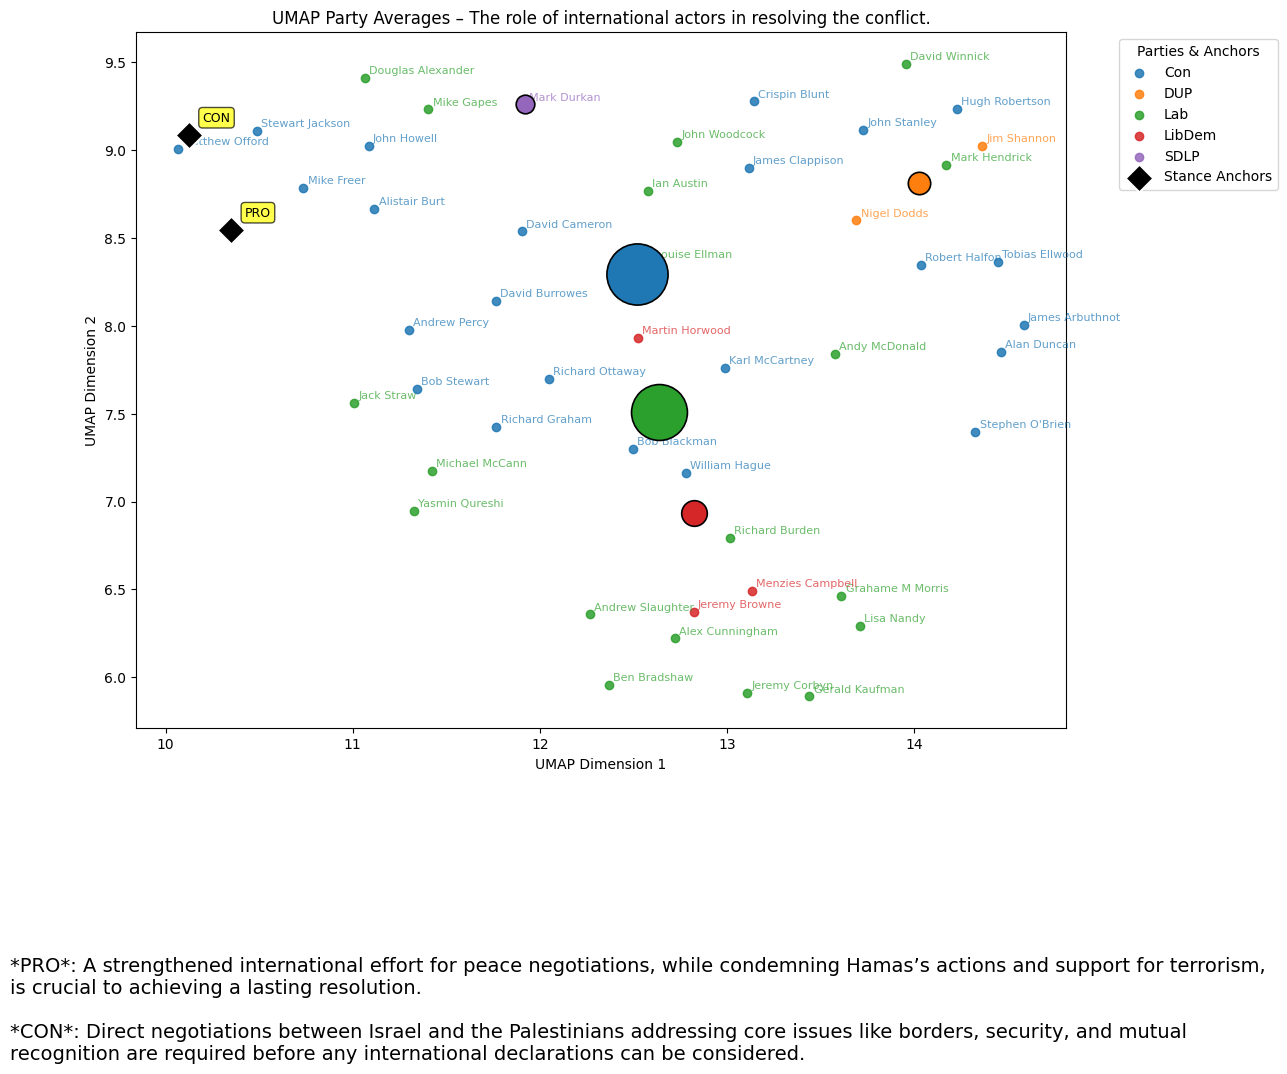

In [23]:
embeddings = uk.compute_umap_embeddings(topic, anchors[3])
uk.plot_umap_party_averages(embeddings, topic)

In [24]:
# compute controversy axis based on anchor 1 (pro) and anchor 0 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[3])
issue = anchors[3]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.45s/it]


,party,controversy_score,issue
3,LibDem,0.053409,The role of international actors in resolving ...
4,SDLP,0.075291,The role of international actors in resolving ...
1,DUP,0.079924,The role of international actors in resolving ...
2,Lab,0.105206,The role of international actors in resolving ...
0,Con,0.169388,The role of international actors in resolving ...


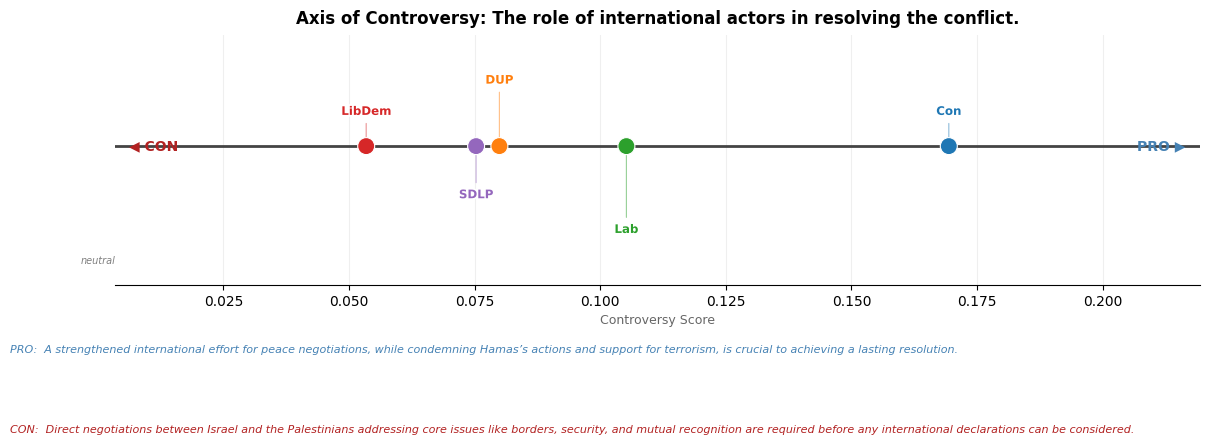

In [25]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[3])

In [26]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[3], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
if 'gaza_metrics_by_anchor' not in globals():
    gaza_metrics_by_anchor = {}
gaza_metrics_by_anchor[3] = metrics
print(metrics)

Predicted ordering: ['LibDem', 'SDLP', 'DUP', 'Lab', 'Con']
Gold standard ordering: ['DUP', 'Con', 'Lab', 'LibDem', 'SDLP']
{'spearman_rho': np.float64(-0.6), 'spearman_p': np.float64(0.2848), 'kendall_tau': np.float64(-0.4), 'kendall_p': np.float64(0.4833), 'lcs_ratio': 0.4, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza
Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.52s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


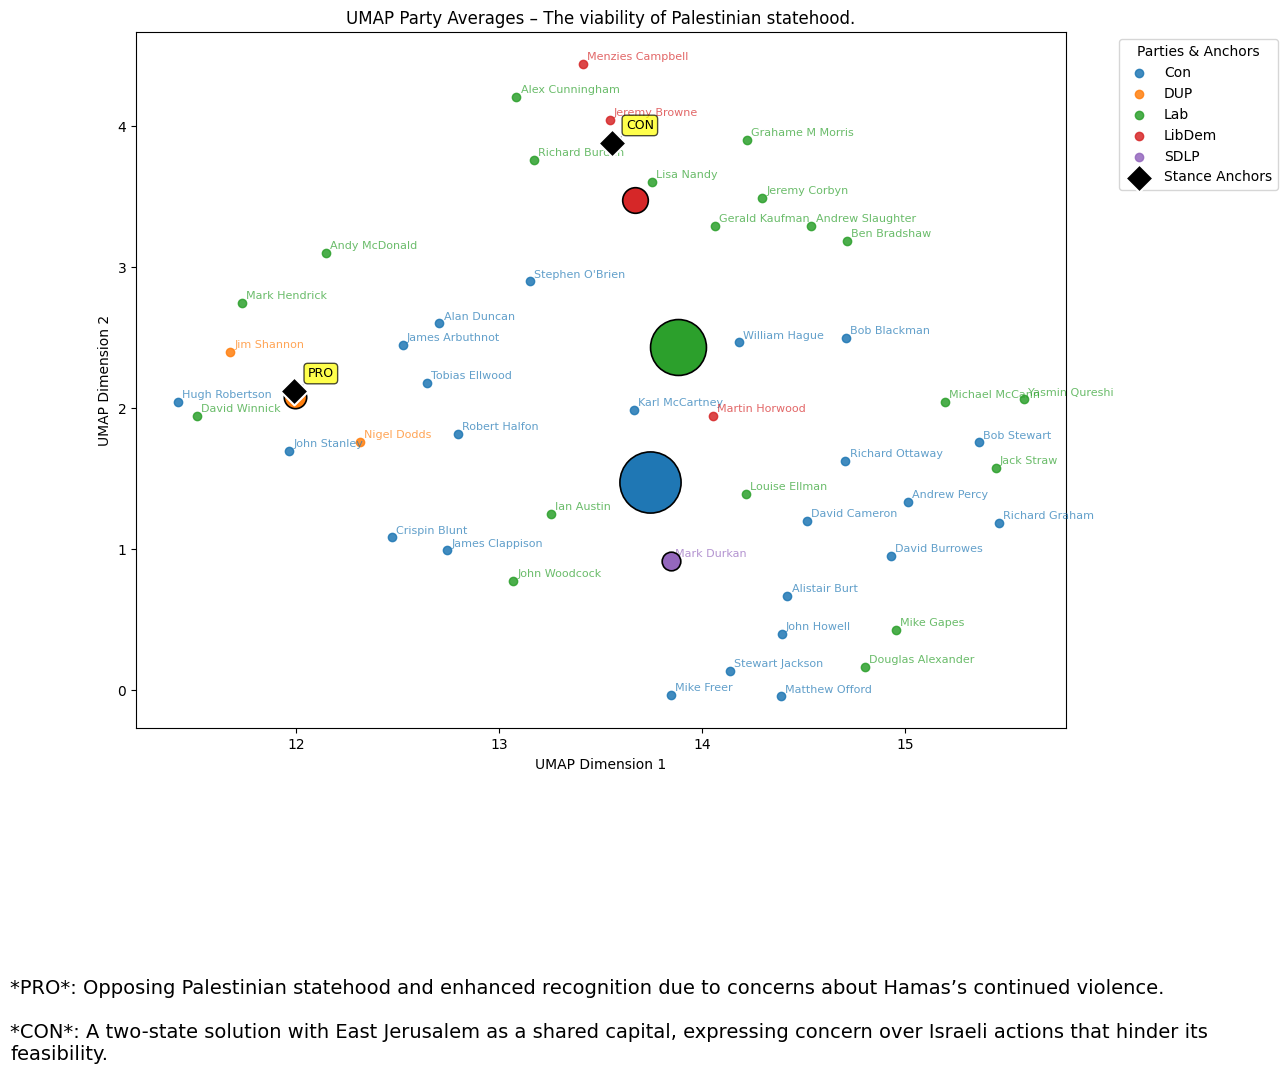

In [27]:
embeddings = uk.compute_umap_embeddings(topic, anchors[5])
uk.plot_umap_party_averages(embeddings, topic)

In [28]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[5])
issue = anchors[5]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.51s/it]


,party,controversy_score,issue
3,LibDem,-0.095641,The viability of Palestinian statehood.
2,Lab,0.059147,The viability of Palestinian statehood.
0,Con,0.113041,The viability of Palestinian statehood.
4,SDLP,0.185554,The viability of Palestinian statehood.
1,DUP,0.250643,The viability of Palestinian statehood.


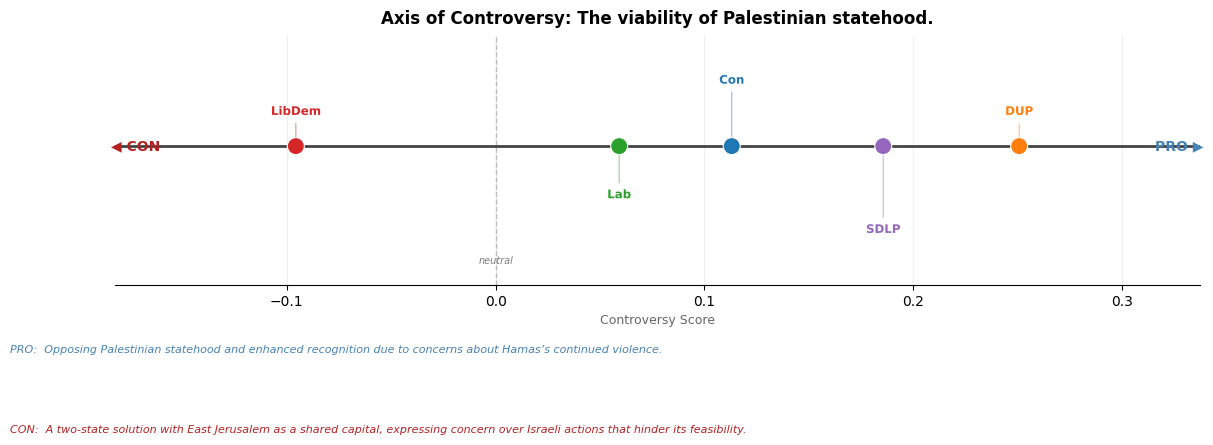

In [29]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[5])

In [30]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[5], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
if 'gaza_metrics_by_anchor' not in globals():
    gaza_metrics_by_anchor = {}
gaza_metrics_by_anchor[5] = metrics
print(metrics)

Predicted ordering: ['LibDem', 'Lab', 'Con', 'SDLP', 'DUP']
Gold standard ordering: ['Lab', 'LibDem', 'SDLP', 'Con', 'DUP']
{'spearman_rho': np.float64(0.8), 'spearman_p': np.float64(0.1041), 'kendall_tau': np.float64(0.6), 'kendall_p': np.float64(0.2333), 'lcs_ratio': 0.6, 'n_parties': 5}


In [33]:
# save metrics on external file
with open(f'./../data/processed/gaza_metrics_by_anchor.json', 'w') as f:
    json.dump(gaza_metrics_by_anchor, f, indent=4)  

In [9]:
# read metrics from external file
with open(f'./../data/processed/gaza_metrics_by_anchor.json', 'r') as f:
    gaza_metrics_by_anchor = json.load(f)

### Comparison: General Anchor vs Sub-topics (Gaza)

The following analysis compares the **general issue anchor** against all generated **sub-topic anchors**.

- `anchor_cosine_similarity`: semantic separation between PRO and CON anchors
- `spearman_rho`, `kendall_tau`, `lcs_ratio`: agreement with LLM-generated gold ordering

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.99s/it]


Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.71s/it]


Computing embeddings for topic: Gaza


...

Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.54s/it]


Computing embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.48s/it]


anchor_label anchor_type  n_parties  anchor_cosine_similarity  spearman_rho  kendall_tau  lcs_ratio
     General     general          5                  0.680157           0.6          0.4        0.6
 Sub-topic 1   sub-topic          5                  0.892658           0.4          0.4        0.8
 Sub-topic 3   sub-topic          5                  0.642928           0.3          0.2        0.6
 Sub-topic 4   sub-topic          5                  0.615753          -0.6         -0.4        0.4
 Sub-topic 6   sub-topic          5                  0.659618           0.8          0.6        0.6


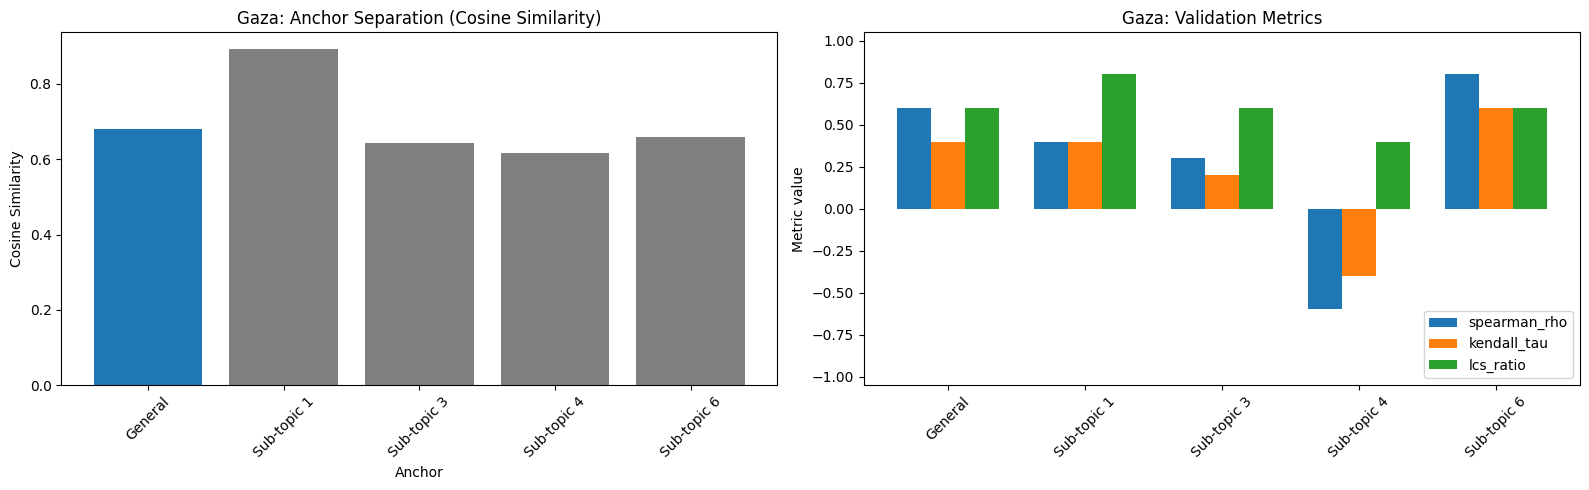

In [24]:
# Comparative visualization for Gaza: general anchor vs sub-topics
gaza_topic = topic
gaza_selected_indices = [0, 2, 3, 5]

def _metrics_for_index(metrics_by_anchor, index):
    if not isinstance(metrics_by_anchor, dict):
        return {}
    return metrics_by_anchor.get(index, metrics_by_anchor.get(str(index), {}))

gaza_general_metrics = gaza_general_metrics if isinstance(gaza_general_metrics, dict) else {}
gaza_metrics_by_anchor = gaza_metrics_by_anchor if isinstance(gaza_metrics_by_anchor, dict) else {}

comparison_rows = []
anchor_sets = [('General', general_anchors, None)] + [
    (f'Sub-topic {i + 1}', anchors[i], i) for i in gaza_selected_indices if i < len(anchors)
]

for label, anchor_set, anchor_index in anchor_sets:
    speaker_embeddings, anchor_embeddings = uk.compute_embeddings(gaza_topic, anchor_set)
    issue = anchor_set['topic']
    party_df = uk.axis_of_controversy(
        gaza_topic,
        issue=issue,
        anchor_embeddings=anchor_embeddings,
        speaker_embeddings=speaker_embeddings,
    ).sort_values(by='controversy_score', ascending=True)

    row = {
        'anchor_label': label,
        'anchor_type': 'general' if anchor_index is None else 'sub-topic',
        'issue': issue,
        'n_parties': len(party_df),
        'anchor_cosine_similarity': uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1]),
        'spearman_rho': None,
        'kendall_tau': None,
        'lcs_ratio': None,
    }

    if anchor_index is None:
        row.update({
            'spearman_rho': gaza_general_metrics.get('spearman_rho'),
            'kendall_tau': gaza_general_metrics.get('kendall_tau'),
            'lcs_ratio': gaza_general_metrics.get('lcs_ratio'),
        })
    else:
        metrics = _metrics_for_index(gaza_metrics_by_anchor, anchor_index)
        row.update({
            'spearman_rho': metrics.get('spearman_rho'),
            'kendall_tau': metrics.get('kendall_tau'),
            'lcs_ratio': metrics.get('lcs_ratio'),
        })

    comparison_rows.append(row)

gaza_comparison_df = pd.DataFrame(comparison_rows)
print(gaza_comparison_df[['anchor_label', 'anchor_type', 'n_parties', 'anchor_cosine_similarity', 'spearman_rho', 'kendall_tau', 'lcs_ratio']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = ['#1f77b4' if t == 'general' else '#7f7f7f' for t in gaza_comparison_df['anchor_type']]

axes[0].bar(gaza_comparison_df['anchor_label'], gaza_comparison_df['anchor_cosine_similarity'], color=bar_colors)
axes[0].set_title('Gaza: Anchor Separation (Cosine Similarity)')
axes[0].set_xlabel('Anchor')
axes[0].set_ylabel('Cosine Similarity')
axes[0].tick_params(axis='x', rotation=45)

metric_cols = ['spearman_rho', 'kendall_tau', 'lcs_ratio']
x = range(len(gaza_comparison_df))
width = 0.25
for i, metric_name in enumerate(metric_cols):
    offsets = [xi + (i - 1) * width for xi in x]
    axes[1].bar(offsets, pd.to_numeric(gaza_comparison_df[metric_name], errors='coerce'), width=width, label=metric_name)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(gaza_comparison_df['anchor_label'], rotation=45)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title('Gaza: Validation Metrics')
axes[1].set_ylabel('Metric value')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## Climate change

The same analysis is also done for the 'Climate change' topic. We start analyzing a general issue, and we then analyze various subtopics.

In [5]:
topic='climate change'

# only considering 2014, because we have a huge amount of data on this topic
years = [2014]

In [7]:
filtered_df= uk.filter_speeches(topic, years=years) 

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2014]: 3256
Classifying filtered speeches for topic: climate change
"Number of opinionated speeches for climate change: 367
Summarization completed for topic: climate change


In [ ]:
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [6]:
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
uk.set_summarization_for_topic(topic, summarizations)

In [25]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: climate change


In [ ]:
with open(f'./../data/processed/anchors_{topic}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [7]:
with open(f'./../data/processed/anchors_{topic}.json', 'r') as f:
    anchors = json.load(f)

In [8]:
general_anchors = {
    "topic": "The role of government intervention in accelerating the UK's transition away from fossil fuels",
    "pro": (
        "Ambitious state investment in renewable energy, binding decarbonisation targets, "
        "and green levies are essential to address climate change, attract long-term "
        "industrial investment, and reduce household dependence on volatile fossil fuel markets."
    ),
    "con": (
        "Government-mandated green energy schemes and carbon reduction targets impose "
        "unsustainable costs on households and energy-intensive industries, distort "
        "market competition, and should give way to technology-neutral, market-led "
        "solutions that prioritise energy security and affordability."
    )
}

Computing UMAP embeddings for topic: climate change
Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.71s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


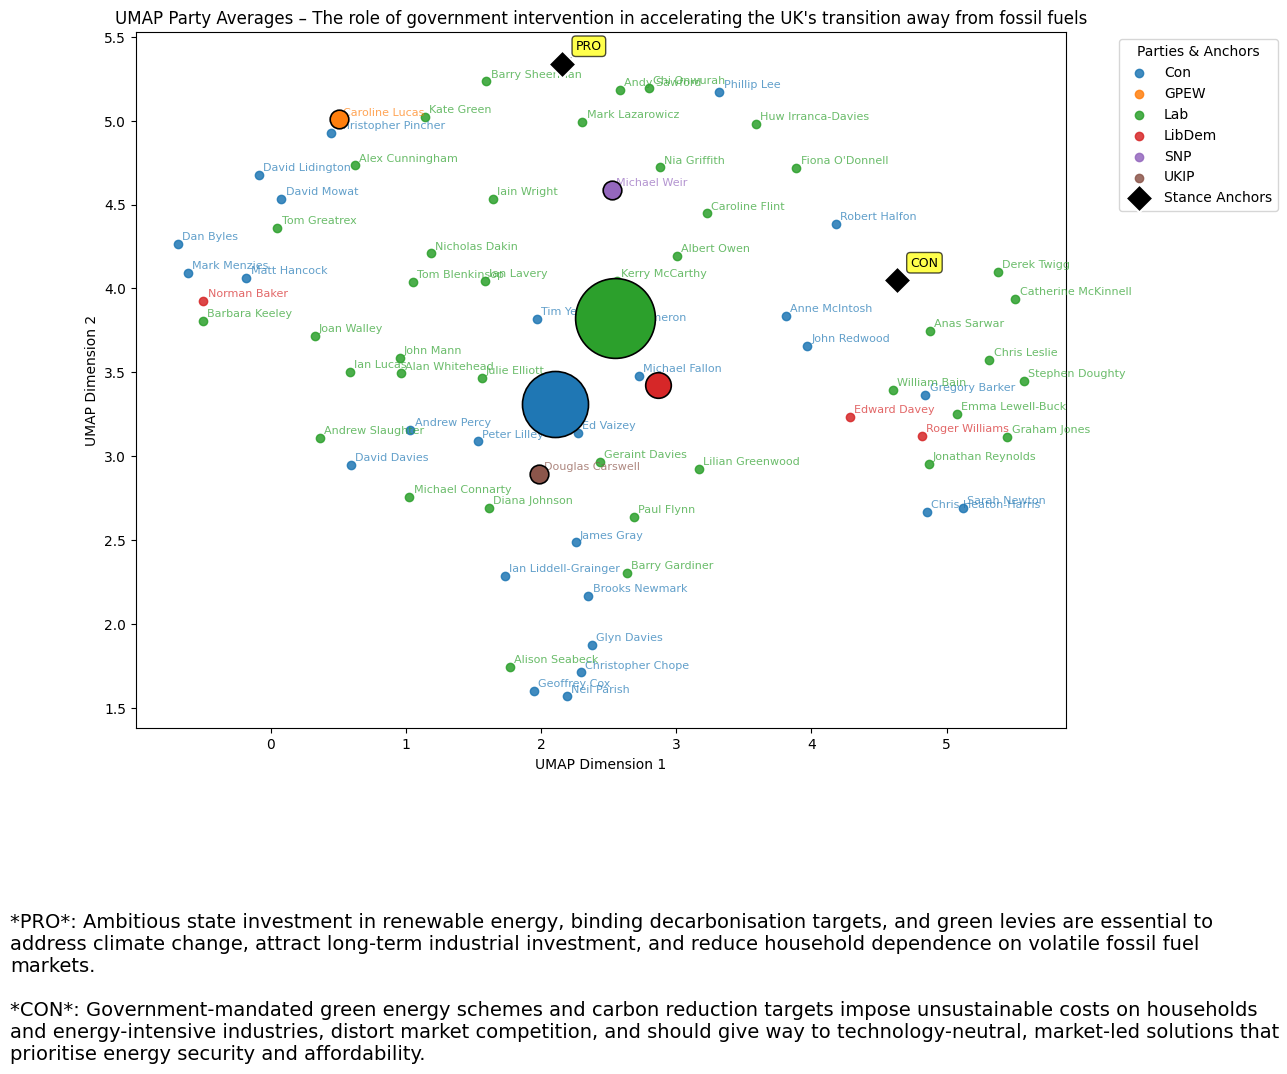

In [13]:
embeddings = uk.compute_umap_embeddings(topic, general_anchors)
uk.plot_umap_party_averages(embeddings, topic)

In [14]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)
issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.76s/it]


,party,controversy_score,issue
3,LibDem,-0.110056,The role of government intervention in acceler...
4,SNP,-0.104163,The role of government intervention in acceler...
0,Con,-0.055657,The role of government intervention in acceler...
2,Lab,-0.037770,The role of government intervention in acceler...
5,UKIP,-0.031491,The role of government intervention in acceler...
1,GPEW,0.153708,The role of government intervention in acceler...


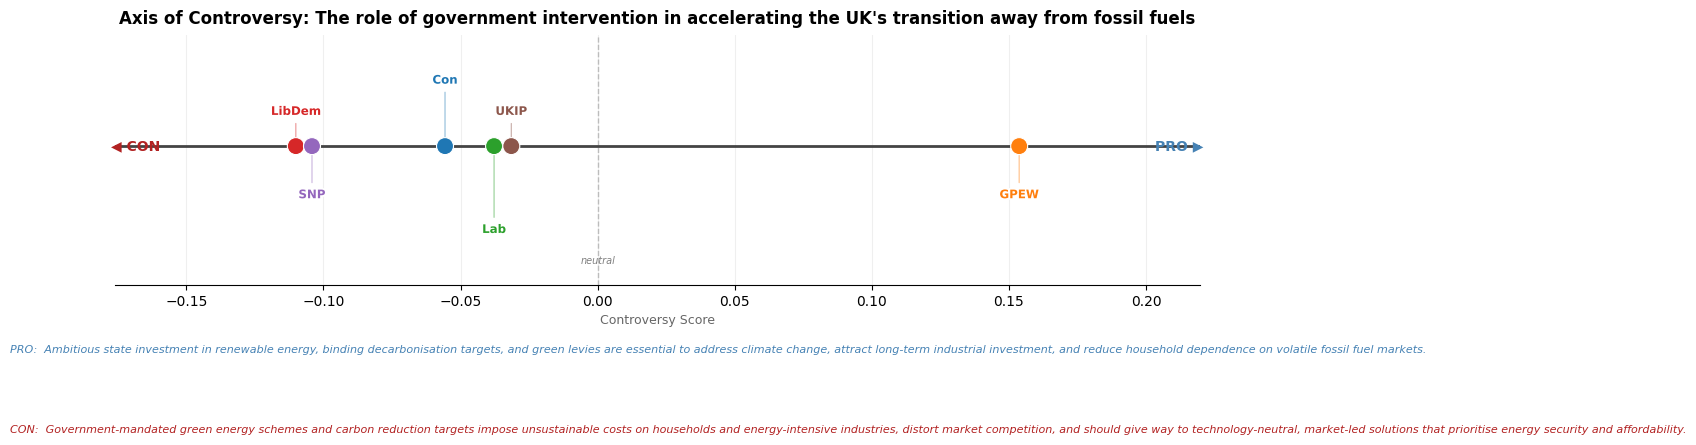

In [15]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

In [16]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=general_anchors, years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
climate_general_metrics = metrics
print(metrics)

Predicted ordering: ['LibDem', 'SNP', 'Con', 'Lab', 'UKIP', 'GPEW']
Gold standard ordering: ['UKIP', 'Con', 'LibDem', 'Lab', 'SNP', 'GPEW']
{'spearman_rho': np.float64(0.1429), 'spearman_p': np.float64(0.7872), 'kendall_tau': np.float64(0.0667), 'kendall_p': np.float64(1.0), 'lcs_ratio': 0.5, 'n_parties': 6}


In [17]:
# save general metrics on external file
with open(f'./../data/processed/general_metrics_{topic}.json', 'w') as f:
    json.dump(climate_general_metrics, f, indent=4)


In [9]:

# load general metrics from external file
with open(f'./../data/processed/general_metrics_{topic}.json', 'r') as f:
    climate_general_metrics = json.load(f)


Computing UMAP embeddings for topic: climate change
Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:10<00:00,  3.40s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


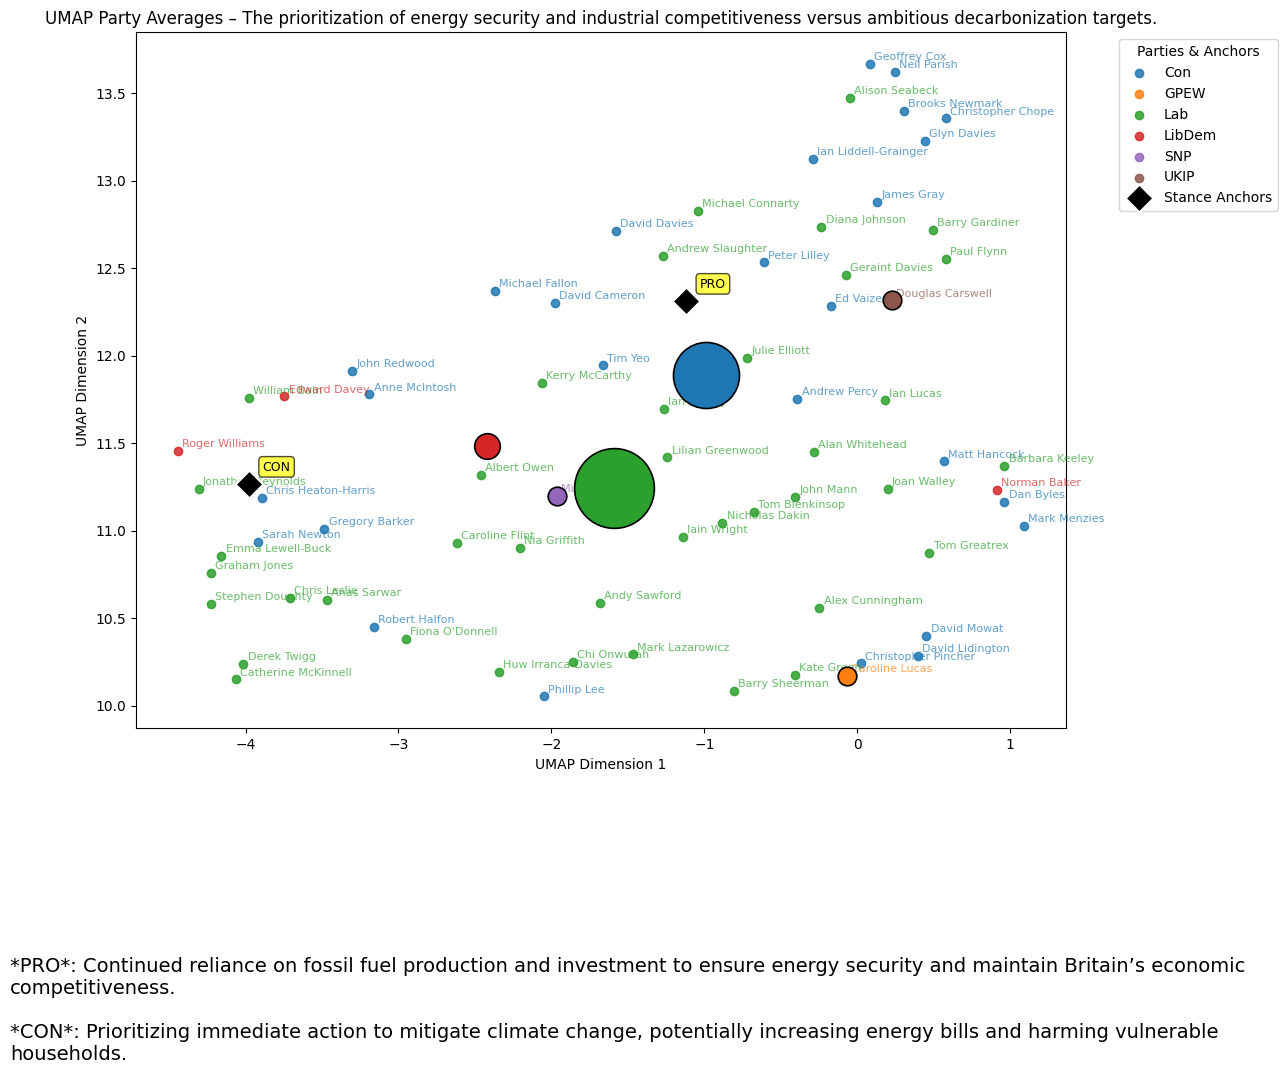

In [19]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [10]:
# generating controversy axis based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[0])
issue = anchors[0]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.85s/it]


,party,controversy_score,issue
3,LibDem,-0.041802,The prioritization of energy security and indu...
2,Lab,-0.036329,The prioritization of energy security and indu...
0,Con,-0.020826,The prioritization of energy security and indu...
4,SNP,0.002098,The prioritization of energy security and indu...
1,GPEW,0.018085,The prioritization of energy security and indu...
5,UKIP,0.042096,The prioritization of energy security and indu...


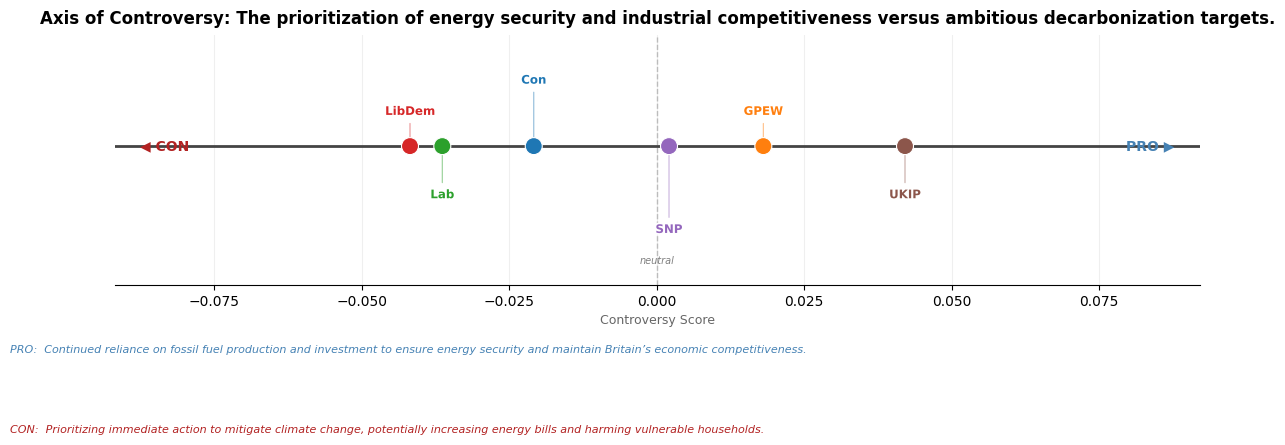

In [11]:
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[0])

In [12]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[0], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
if 'climate_change_metrics_by_anchor' not in globals():
    climate_change_metrics_by_anchor = {}
climate_change_metrics_by_anchor[0] = metrics
print(metrics)


Predicted ordering: ['LibDem', 'Lab', 'Con', 'SNP', 'GPEW', 'UKIP']
Gold standard ordering: ['GPEW', 'SNP', 'Lab', 'LibDem', 'UKIP', 'Con']
{'spearman_rho': np.float64(-0.1429), 'spearman_p': np.float64(0.7872), 'kendall_tau': np.float64(-0.2), 'kendall_p': np.float64(0.7194), 'lcs_ratio': 0.3333, 'n_parties': 6}


Computing UMAP embeddings for topic: climate change
Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


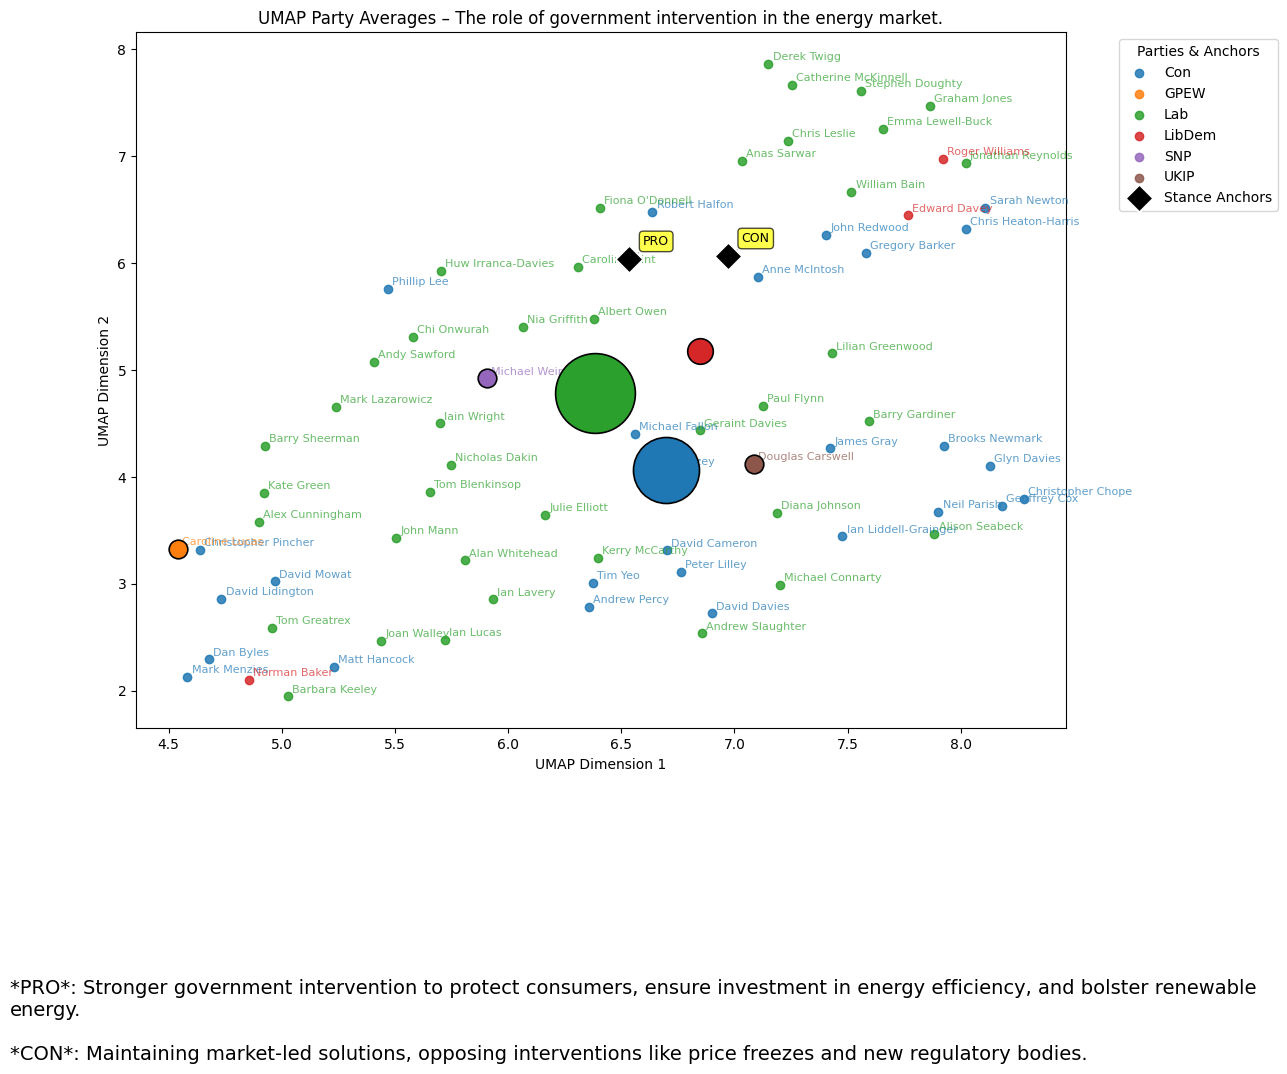

In [13]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

In [14]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[1])
issue = anchors[1]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:09<00:00,  3.03s/it]


,party,controversy_score,issue
3,LibDem,-0.026504,The role of government intervention in the ene...
0,Con,0.035098,The role of government intervention in the ene...
2,Lab,0.059223,The role of government intervention in the ene...
4,SNP,0.103383,The role of government intervention in the ene...
1,GPEW,0.104376,The role of government intervention in the ene...
5,UKIP,0.123792,The role of government intervention in the ene...


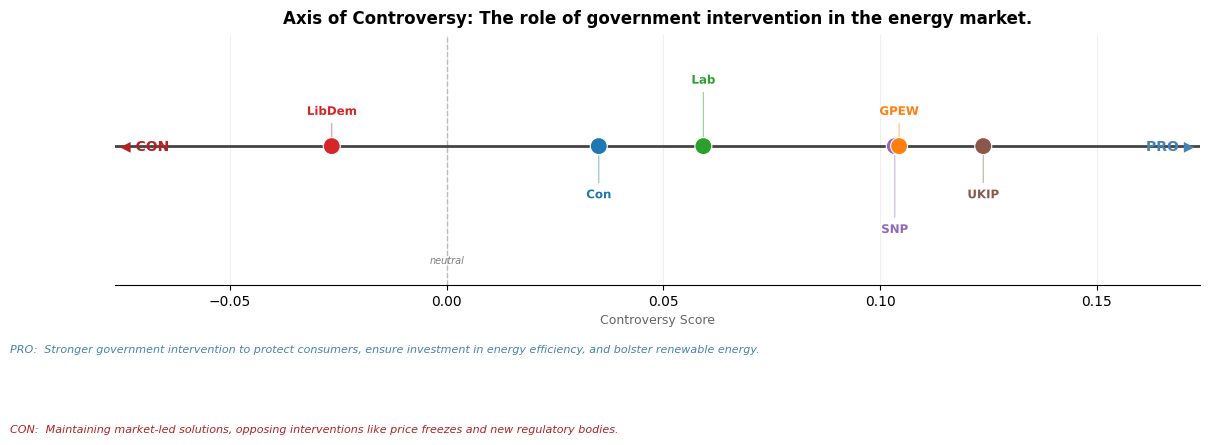

In [15]:
# visualize controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[1])

In [16]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[1], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
climate_change_metrics_by_anchor[1] = metrics
print(metrics)


Predicted ordering: ['LibDem', 'Con', 'Lab', 'SNP', 'GPEW', 'UKIP']
Gold standard ordering: ['UKIP', 'LibDem', 'Con', 'Lab', 'SNP', 'GPEW']
{'spearman_rho': np.float64(0.1429), 'spearman_p': np.float64(0.7872), 'kendall_tau': np.float64(0.3333), 'kendall_p': np.float64(0.4694), 'lcs_ratio': 0.8333, 'n_parties': 6}


Computing UMAP embeddings for topic: climate change
Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:07<00:00,  2.39s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


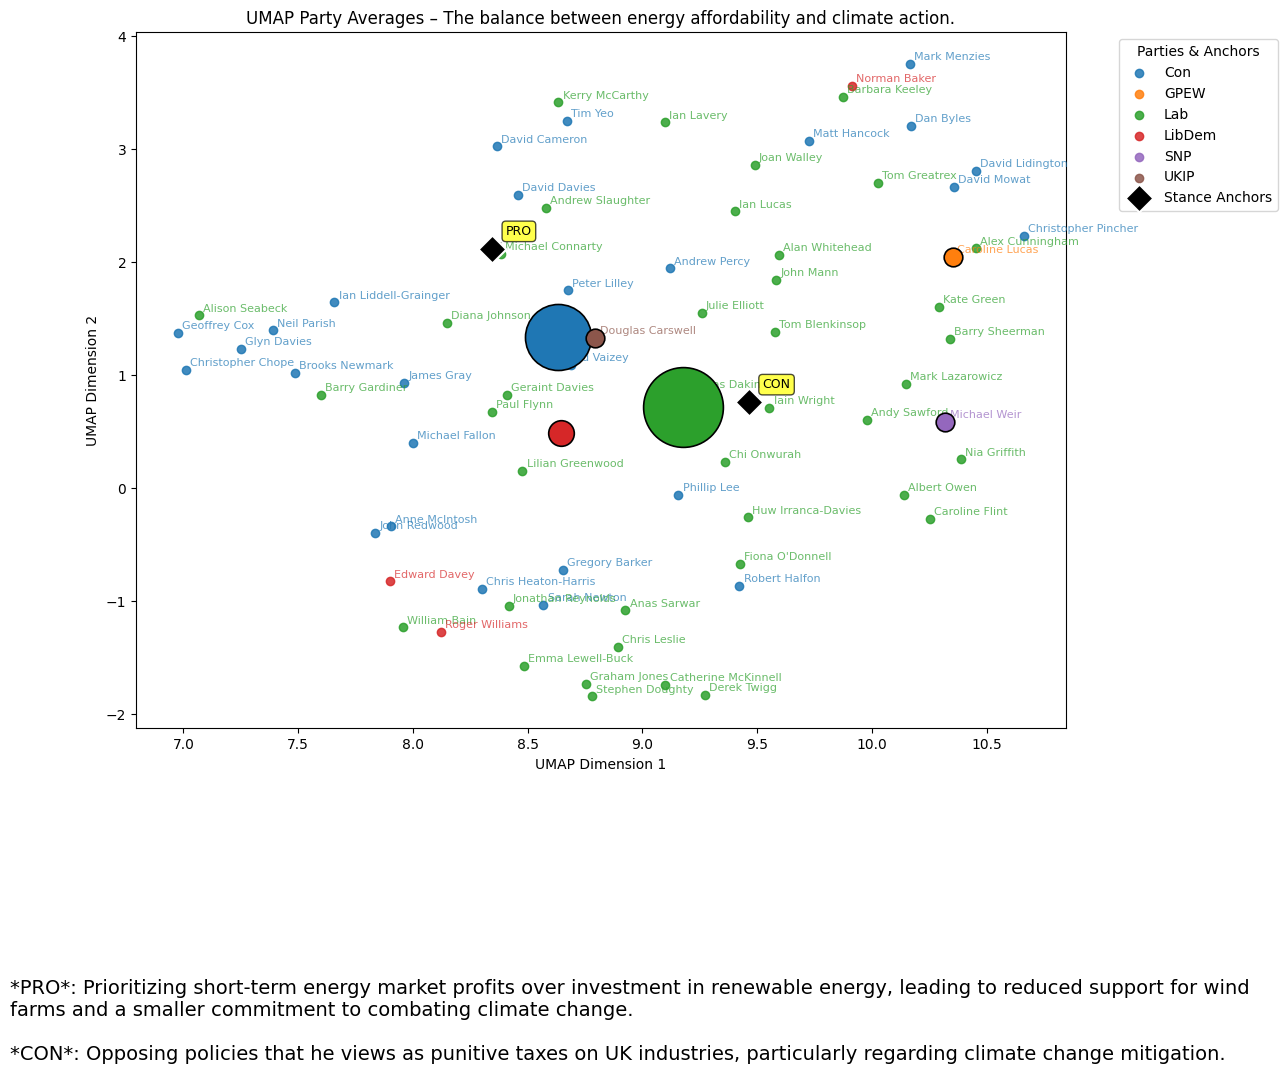

In [38]:
embeddings = uk.compute_umap_embeddings(topic, anchors[3])
uk.plot_umap_party_averages(embeddings, topic)

In [17]:
# controversy axis based on anchor 3 (pro) and anchor 4 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[3])
issue = anchors[3]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.87s/it]


,party,controversy_score,issue
1,GPEW,-0.108571,The balance between energy affordability and c...
2,Lab,-0.053284,The balance between energy affordability and c...
5,UKIP,-0.034498,The balance between energy affordability and c...
3,LibDem,-0.006922,The balance between energy affordability and c...
0,Con,0.000393,The balance between energy affordability and c...
4,SNP,0.088876,The balance between energy affordability and c...


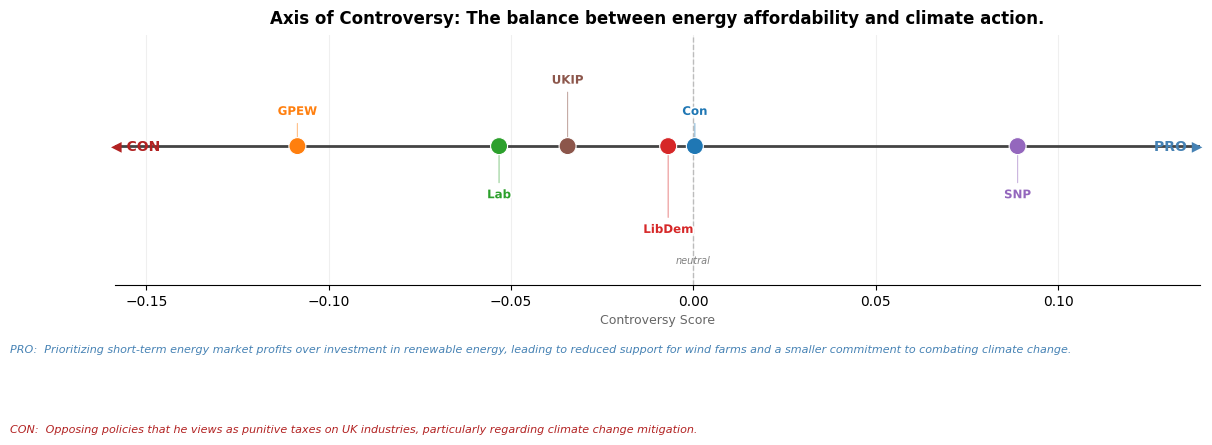

In [40]:
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[3])

In [18]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[3], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
climate_change_metrics_by_anchor[3] = metrics
print(metrics)


Predicted ordering: ['GPEW', 'Lab', 'UKIP', 'LibDem', 'Con', 'SNP']
Gold standard ordering: ['SNP', 'LibDem', 'GPEW', 'Con', 'Lab', 'UKIP']
{'spearman_rho': np.float64(-0.4857), 'spearman_p': np.float64(0.3287), 'kendall_tau': np.float64(-0.3333), 'kendall_p': np.float64(0.4694), 'lcs_ratio': 0.5, 'n_parties': 6}


In [19]:
# save metrics on external file
with open(f'./../data/processed/climate_change_metrics_by_anchor.json', 'w') as f:
    json.dump(climate_change_metrics_by_anchor, f, indent=4)

# load metrics from external file
with open(f'./../data/processed/climate_change_metrics_by_anchor.json', 'r') as f:
    climate_change_metrics_by_anchor = json.load(f)


### Comparison: General Anchor vs Sub-topics (Climate Change)

The following analysis compares the **general issue anchor** against all generated **sub-topic anchors**.

- `anchor_cosine_similarity`: semantic separation between PRO and CON anchors
- `spearman_rho`, `kendall_tau`, `lcs_ratio`: agreement with LLM-generated gold ordering

Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.94s/it]


Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:09<00:00,  3.11s/it]


Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:08<00:00,  2.96s/it]


Computing embeddings for topic: climate change


Batches: 100%|██████████| 3/3 [00:09<00:00,  3.01s/it]


anchor_label anchor_type  n_parties  anchor_cosine_similarity  spearman_rho  kendall_tau  lcs_ratio
     General     general          6                  0.669758        0.1429       0.0667     0.5000
 Sub-topic 1   sub-topic          6                  0.454168       -0.1429      -0.2000     0.3333
 Sub-topic 2   sub-topic          6                  0.590058        0.1429       0.3333     0.8333
 Sub-topic 4   sub-topic          6                  0.553883       -0.4857      -0.3333     0.5000


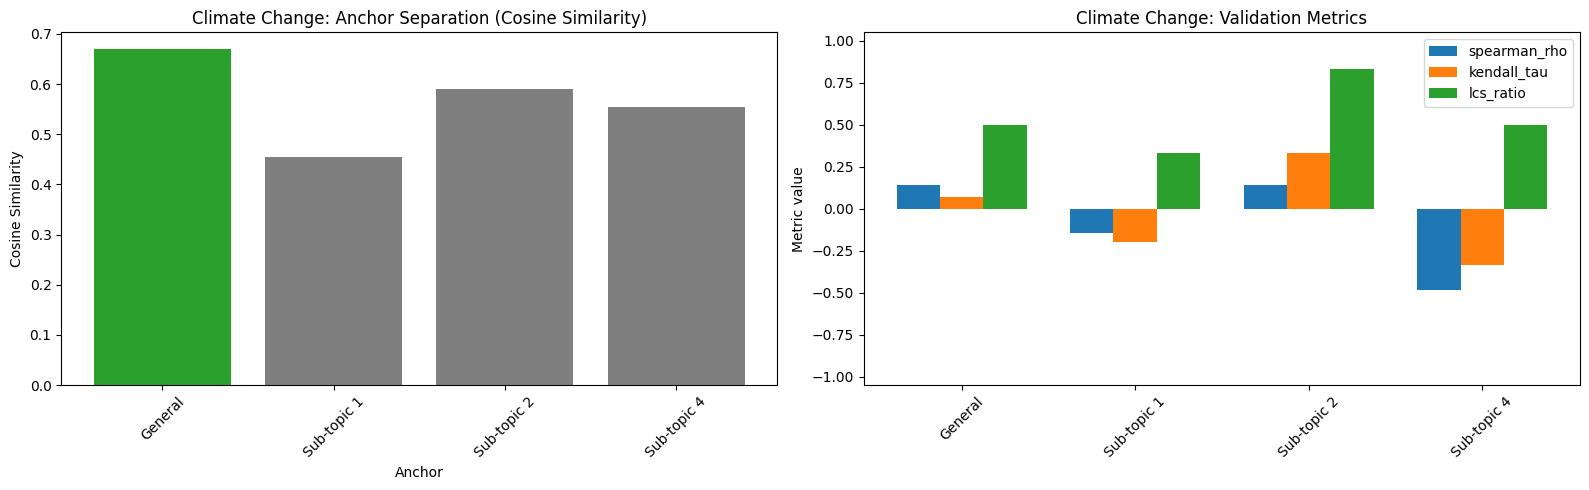

In [20]:
# Comparative visualization for Climate Change: general anchor vs sub-topics
climate_topic = topic
climate_selected_indices = [0, 1, 3]

def _metrics_for_index(metrics_by_anchor, index):
    if not isinstance(metrics_by_anchor, dict):
        return {}
    return metrics_by_anchor.get(index, metrics_by_anchor.get(str(index), {}))

climate_general_metrics = climate_general_metrics if isinstance(climate_general_metrics, dict) else {}
climate_change_metrics_by_anchor = climate_change_metrics_by_anchor if isinstance(climate_change_metrics_by_anchor, dict) else {}

comparison_rows = []
anchor_sets = [('General', general_anchors, None)] + [
    (f'Sub-topic {i + 1}', anchors[i], i) for i in climate_selected_indices if i < len(anchors)
]

for label, anchor_set, anchor_index in anchor_sets:
    speaker_embeddings, anchor_embeddings = uk.compute_embeddings(climate_topic, anchor_set)
    issue = anchor_set['topic']
    party_df = uk.axis_of_controversy(
        climate_topic,
        issue=issue,
        anchor_embeddings=anchor_embeddings,
        speaker_embeddings=speaker_embeddings,
    ).sort_values(by='controversy_score', ascending=True)

    row = {
        'anchor_label': label,
        'anchor_type': 'general' if anchor_index is None else 'sub-topic',
        'issue': issue,
        'n_parties': len(party_df),
        'anchor_cosine_similarity': uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1]),
        'spearman_rho': None,
        'kendall_tau': None,
        'lcs_ratio': None,
    }

    if anchor_index is None:
        row.update({
            'spearman_rho': climate_general_metrics.get('spearman_rho'),
            'kendall_tau': climate_general_metrics.get('kendall_tau'),
            'lcs_ratio': climate_general_metrics.get('lcs_ratio'),
        })
    else:
        metrics = _metrics_for_index(climate_change_metrics_by_anchor, anchor_index)
        row.update({
            'spearman_rho': metrics.get('spearman_rho'),
            'kendall_tau': metrics.get('kendall_tau'),
            'lcs_ratio': metrics.get('lcs_ratio'),
        })

    comparison_rows.append(row)

climate_comparison_df = pd.DataFrame(comparison_rows)
print(climate_comparison_df[['anchor_label', 'anchor_type', 'n_parties', 'anchor_cosine_similarity', 'spearman_rho', 'kendall_tau', 'lcs_ratio']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = ['#2ca02c' if t == 'general' else '#7f7f7f' for t in climate_comparison_df['anchor_type']]

axes[0].bar(climate_comparison_df['anchor_label'], climate_comparison_df['anchor_cosine_similarity'], color=bar_colors)
axes[0].set_title('Climate Change: Anchor Separation (Cosine Similarity)')
axes[0].set_xlabel('Anchor')
axes[0].set_ylabel('Cosine Similarity')
axes[0].tick_params(axis='x', rotation=45)

metric_cols = ['spearman_rho', 'kendall_tau', 'lcs_ratio']
x = range(len(climate_comparison_df))
width = 0.25
for i, metric_name in enumerate(metric_cols):
    offsets = [xi + (i - 1) * width for xi in x]
    axes[1].bar(offsets, pd.to_numeric(climate_comparison_df[metric_name], errors='coerce'), width=width, label=metric_name)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(climate_comparison_df['anchor_label'], rotation=45)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title('Climate Change: Validation Metrics')
axes[1].set_ylabel('Metric value')
axes[1].legend()
plt.tight_layout()
plt.show()

## Improvements and Future Work

Several limitations of the current approach suggest directions for future work:

- **Summarization granularity** — Speaker summaries are currently generated 
at the topic level. Generating sub-topic-level summaries could improve 
performance on narrower axes of controversy, at the cost of increased 
computational load.

- **Minimum representation threshold** — Parties with very few representatives 
in the filtered speeches (e.g. UKIP for 'Climate Change', represented solely by Douglas Carswell) 
produce unreliable centroid estimates, as the stance signal can be overwhelmed by vocabulary used to describe a certain topic ('renewable energies', 'investment', 'subsidies). A minimum threshold on the number of speakers per party should be enforced before including a party in the evaluation.

- **Statistical power** — With only 4–6 parties, rank correlation metrics 
(Spearman's ρ, Kendall's τ) have high variance and limited statistical power. 
Two possible mitigations are: 
    - evaluating at the politician level rather 
than the party level, significantly increasing the number of ranked entities

    - aggregating validation results across multiple related sub-topics or 
extended time periods.

- **Gold standard reliability** — The LLM-generated gold standard reflects 
general world knowledge about party ideology, rather than what MPs actually 
said in the specific time period under analysis. Running the gold standard 
generation multiple times and aggregating via median ranks could mitigate 
this inconsistency.

- **Anchor quality** — The quality of the controversy axis depends heavily on 
the semantic distance between the PRO and CON anchors. A cosine similarity 
threshold check on the generated anchor pairs could serve as an automatic 
quality gate, filtering out poorly separated anchors before projection.


## References
[1] Sylvester, C. (Creator), Greene, Z. (Creator), Ershova, A. (Contributor), Khokhlova, A. (Contributor), Yordanova, N. (Creator) (21 Feb 2023). ParlEE plenary speeches V2 data set: Annotated full-text of 15.1 million sentence-level plenary speeches of six EU legislative chambers. Harvard Dataverse. 10.7910/DVN/VOPK0E

[2] Kato, Ken & Cochrane, Christopher. (2025). KOKKAI DOC: An LLM-driven framework for scaling parliamentary representatives. 10.48550/arXiv.2505.07118. 